In [ ]:
mean_hourly = [2, 3, 2, 4, 3, 7, # 1-6 AM
               9, 13, 16, 11, 10, 15, # 7-12 AM
               18,12, 11, 18, 17, 20, # 13-18 PM
               20 , 19, 17, 9, 7, 6]  # 19-24 PM

std_hourly = [2, 3, 2, 4, 3, 7, # 1-6 AM
              9, 13, 16, 11, 10, 15, # 7-12 AM
              18, 12, 11, 18, # 13-18 PM
              20, 19, 9, 5]  # 19-24 PM

In [4]:

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import json, os

os.makedirs("output", exist_ok=True)

# ── Base profiles ────────────────────────────────────────────────────────────
mean_hourly_base = [2, 3, 2, 4, 3, 7,        # 1-6 AM
                    9, 13, 16, 11, 10, 15,     # 7-12 AM
                    18, 12, 11, 18, 17, 20,    # 13-18 PM
                    20, 19, 17, 9, 7, 6]       # 19-24 PM

std_hourly_base  = [2, 3, 2, 4, 3, 7,
                    9, 13, 16, 11, 10, 15,
                    18, 12, 11, 18,
                    20, 19, 9, 5]  # only 20 values → pad to 24
# Pad std to 24 hours by repeating the last value
while len(std_hourly_base) < 24:
    std_hourly_base.append(std_hourly_base[-1])

mean_hourly_base = np.array(mean_hourly_base, dtype=float)
std_hourly_base  = np.array(std_hourly_base,  dtype=float)

hours = np.arange(1, 25)

# ── 5 profile variants (different mean/std scalings) ─────────────────────────
PROFILE_VARIANTS = [
    {"name": "Base",       "mean_scale": 1.0,  "std_scale": 1.0,  "mean_shift": 0},
    {"name": "High-Load",  "mean_scale": 1.5,  "std_scale": 1.2,  "mean_shift": 3},
    {"name": "Low-Load",   "mean_scale": 0.6,  "std_scale": 0.7,  "mean_shift": -1},
    {"name": "Morning-Pk", "mean_scale": 1.0,  "std_scale": 1.0,  "mean_shift": 0},
    {"name": "Evening-Pk", "mean_scale": 1.0,  "std_scale": 1.1,  "mean_shift": 0},
]

def make_profile(variant):
    """Return (mean_24, std_24) for a variant."""
    m = mean_hourly_base * variant["mean_scale"] + variant["mean_shift"]
    s = std_hourly_base  * variant["std_scale"]
    if variant["name"] == "Morning-Pk":      # boost 6-9 AM
        m[5:9]  *= 1.8
        s[5:9]  *= 1.5
    elif variant["name"] == "Evening-Pk":    # boost 18-21 PM
        m[17:21] *= 1.6
        s[17:21] *= 1.4
    return np.clip(m, 0, None), np.clip(s, 0.1, None)

# ── Household transformations ─────────────────────────────────────────────────
# 4 household archetypes applied via (mean_offset, std_mult, time_shift_hours)
HOUSEHOLD_TRANSFORMS = [
    {"hh": 0, "label": "HH-A: Std",       "mean_offset":  0, "std_mult": 1.0, "shift": 0},
    {"hh": 1, "label": "HH-B: NightOwl",  "mean_offset": -2, "std_mult": 0.9, "shift": 3},   # shifted 3h late
    {"hh": 2, "label": "HH-C: EarlyBird", "mean_offset":  1, "std_mult": 1.1, "shift": -2},  # 2h earlier
    {"hh": 3, "label": "HH-D: HighUse",   "mean_offset":  4, "std_mult": 1.4, "shift": 0},
]

# ── Group-based scaling (group id 0-3 adds multiplicative factor) ─────────────
def group_scale(group_id):
    """Returns multiplicative factor for demand based on group."""
    return 1.0 + 0.25 * group_id   # groups 0-3 → ×1.0, ×1.25, ×1.50, ×1.75

# ── DGM: Deep Generative Mechanism ───────────────────────────────────────────
def dgm_generate(mean_24, std_24, n_samples=50,
                 hh_transform=None, group_id=0,
                 outlier_frac=0.05, rng=None):
    """
    Generate synthetic hourly demand profiles.

    Parameters
    ----------
    mean_24      : (24,) hourly mean demand
    std_24       : (24,) hourly std  demand
    n_samples    : number of households/days to generate
    hh_transform : dict with keys mean_offset, std_mult, shift
    group_id     : int 0-3, adds a multiplicative scaling
    outlier_frac : fraction of samples to inject outliers into
    rng          : np.random.Generator

    Returns
    -------
    profiles : (n_samples, 24) array
    """
    if rng is None:
        rng = np.random.default_rng(42)

    m = mean_24.copy()
    s = std_24.copy()

    # ── household transformation ──────────────────────────────────────────────
    if hh_transform is not None:
        m  = np.roll(m, hh_transform["shift"]) + hh_transform["mean_offset"]
        s  = np.roll(s, hh_transform["shift"]) * hh_transform["std_mult"]
        m  = np.clip(m, 0, None)
        s  = np.clip(s, 0.1, None)

    # ── group scaling ─────────────────────────────────────────────────────────
    gscale = group_scale(group_id)
    m = m * gscale
    s = s * np.sqrt(gscale)          # variance ∝ mean → std ∝ sqrt

    # ── sample from truncated normal (demand ≥ 0) ─────────────────────────────
    profiles = np.zeros((n_samples, 24))
    for h in range(24):
        raw = rng.normal(m[h], s[h], n_samples)
        profiles[:, h] = np.clip(raw, 0, None)

    # ── inject outliers ───────────────────────────────────────────────────────
    n_outliers = max(1, int(n_samples * outlier_frac))
    outlier_idx = rng.choice(n_samples, size=n_outliers, replace=False)
    for idx in outlier_idx:
        spike_hour = rng.integers(0, 24)
        profiles[idx, spike_hour] += rng.uniform(2.5, 4.0) * m[spike_hour]

    return profiles

# ── Generate all data ─────────────────────────────────────────────────────────
N_SAMPLES   = 100   # per (variant × household × group)
N_GROUPS    = 4
rng_master  = np.random.default_rng(2024)

records = []
for var in PROFILE_VARIANTS:
    m_v, s_v = make_profile(var)
    for hht in HOUSEHOLD_TRANSFORMS:
        for gid in range(N_GROUPS):
            seed = rng_master.integers(0, 99999)
            profs = dgm_generate(m_v, s_v,
                                 n_samples=N_SAMPLES,
                                 hh_transform=hht,
                                 group_id=gid,
                                 outlier_frac=0.05,
                                 rng=np.random.default_rng(seed))
            for i, p in enumerate(profs):
                records.append({
                    "variant":    var["name"],
                    "household":  hht["label"],
                    "group_id":   gid,
                    "sample_id":  i,
                    **{f"h{h+1:02d}": p[h] for h in range(24)}
                })

df = pd.DataFrame(records)
df.to_csv("output/dgm_profiles.csv", index=False)
print(f"Generated {len(df)} profiles | columns: {list(df.columns[:8])} ...")

Generated 8000 profiles | columns: ['variant', 'household', 'group_id', 'sample_id', 'h01', 'h02', 'h03', 'h04'] ...


ModuleNotFoundError: No module named 'matplotlib'

In [16]:

import pandas as pd

url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

# Load the CSV into a DataFrame
df_T23_100samples = pd.read_csv(url_for_design)


In [26]:
df_T23_100samples

,1,2,3,4
0,18.645368,9.158402,26.734796,10.112260
1,22.032234,9.625420,26.649974,10.700635
2,21.736908,10.549740,22.908477,9.689246
3,17.833949,10.401562,23.383460,9.950623
4,26.168801,11.229433,25.427600,10.460829
...,...,...,...,...
95,23.820519,11.091908,23.826393,12.179594
96,20.267862,8.976766,28.876014,12.160038
97,18.818888,9.067854,25.389628,10.836643
98,20.307448,11.237359,26.663823,9.116900


In [63]:
import numpy as np
import pandas as pd

# ── Base profiles ────────────────────────────────────────────────────────────
mean_hourly_base_2_4 = np.array([
    3, 4, 2, 4, 6, 6,
    10, 10, 10, 10, 10, 15,
    12, 10, 11, 10, 12, 12,
    10, 10, 10, 9, 7, 6
], dtype=float)

mean_hourly_base_1_3 = np.array([
    10, 10, 8, 7, 9, 9,
    19, 19, 13, 20, 25, 25,
    25, 15, 13, 13, 13, 21,
    18, 18, 13, 13, 11, 11
], dtype=float)



Coeff_Groups = { 'G5': [1., 1.2, 0.2, 0.3],
                 'G6': [1., 1., 0.12, 0.24], }



def generate_loads(n_sam_day,
                   group='G6',
                   sampler="independent",
                   clip_negative=True,
                   corr_matrix=None,
                   seed=None):

    rng = np.random.default_rng(seed)

    mu_2_4_gk = mean_hourly_base_2_4 * Coeff_Groups[group][0]
    mu_1_3_gk = mean_hourly_base_1_3 * Coeff_Groups[group][1]
    std_2_4_gk = mean_hourly_base_2_4 * Coeff_Groups[group][2]
    std_1_3_gk = mean_hourly_base_1_3 * Coeff_Groups[group][3]

    dfs = []

    for day in range(n_sam_day):

        if sampler == "independent":
            node_1 = rng.normal(loc=mean_hourly_base_1_3, scale=mu_1_3_gk)
            node_2 = rng.normal(loc=mean_hourly_base_2_4, scale=mu_2_4_gk)
            node_3 = rng.normal(loc=mean_hourly_base_1_3, scale=std_1_3_gk)
            node_4 = rng.normal(loc=mean_hourly_base_2_4, scale=std_2_4_gk)

            # optional: clip negative values
            if clip_negative:
                node_1 = np.clip(node_1, 0, None)
                node_2 = np.clip(node_2, 0, None)
                node_3 = np.clip(node_3, 0, None)
                node_4 = np.clip(node_4, 0, None)

            df_day = pd.DataFrame({
                "day": day + 1,
                "hour": np.arange(1, 25),
                "node_1": node_1,
                "node_2": node_2,
                "node_3": node_3,
                "node_4": node_4,
            })

        elif sampler == "spatial":

            if corr_matrix is None:
                corr_matrix = np.array([
                                        [1.0, 0.7, 0.9, 0.6],
                                        [0.7, 1.0, 0.6, 0.85],
                                        [0.9, 0.6, 1.0, 0.7],
                                        [0.6, 0.85, 0.7, 1.0], ])

            corr_matrix = np.asarray(corr_matrix, dtype=float)

            if corr_matrix.shape != (4, 4):
                raise ValueError("corr_matrix must be 4x4.")

            if not np.allclose(corr_matrix, corr_matrix.T):
                raise ValueError("corr_matrix must be symmetric.")

            df_rows = []
            for h in range(24):
                mu_h = np.array([
                    mean_hourly_base_1_3[h],
                    mean_hourly_base_2_4[h],
                    mean_hourly_base_1_3[h],
                    mean_hourly_base_2_4[h],
                ])

                std_h = np.array([
                    std_1_3[h],
                    std_2_4[h],
                    std_1_3[h],
                    std_2_4[h],
                ])

                cov_h = np.outer(std_h, std_h) * corr_matrix

                sample_h = rng.multivariate_normal(mean=mu_h, cov=cov_h)

                if clip_negative:
                    sample_h = np.clip(sample_h, 0, None)

                df_rows.append({
                    "day": day + 1,
                    "hour": h + 1,
                    "node_1": sample_h[0],
                    "node_2": sample_h[1],
                    "node_3": sample_h[2],
                    "node_4": sample_h[3],
                })

            df_day = pd.DataFrame(df_rows)

        else:
            raise ValueError("sampler must be either 'independent' or 'spatial'.")


        dfs.append(df_day)
    df_loads = pd.concat(dfs, ignore_index=True)
    df_no_time_id = df_loads[[ "node_1", "node_2", "node_3", "node_4"]]
    df_no_time_id.to_pickle("generated_loads"+group)

    return df_loads

In [67]:
df_loads = generate_loads(30, group='G5', sampler='spatial', seed=42)
df_loads = generate_loads(30, group='G6', sampler='spatial', seed=42)
print(df_loads.head(10))

   day  hour     node_1     node_2     node_3     node_4
0    1     1   8.668430   2.913993   9.699418   3.546191
1    1     2  13.827761   5.007954  15.248267   5.449358
2    1     3   8.496903   1.711215   7.722318   1.605829
3    1     4   6.481751   3.763061   7.363018   3.894064
4    1     5   7.661209   6.071200   8.588504   6.385080
5    1     6   8.916036   6.571668   9.583026   6.770356
6    1     7  21.399388   9.969118  20.633164   9.882495
7    1     8  17.163674   7.487856  18.095581   7.610575
8    1     9  14.825407  11.277880  13.764761  11.260745
9    1    10  21.327113  10.961959  19.454313  10.700153


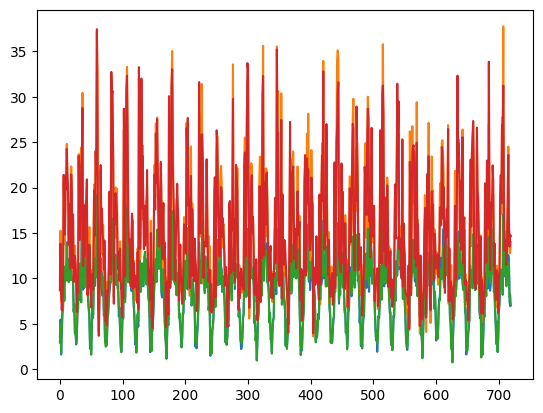

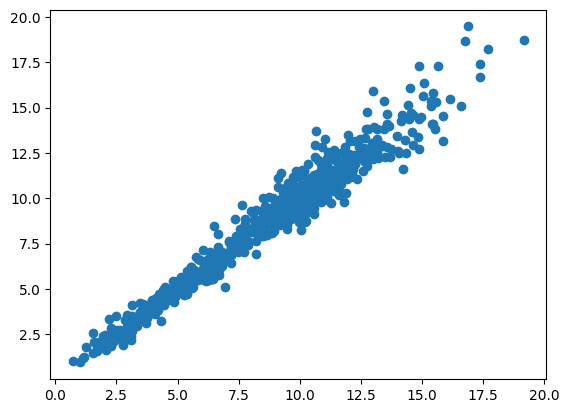

In [68]:
import matplotlib.pyplot as plt
plt.plot(df_loads['node_4'])
plt.plot(df_loads['node_3'])
plt.plot(df_loads['node_2'])
plt.plot(df_loads['node_1'])
plt.show()

plt.scatter(df_loads['node_2'],df_loads['node_4'])